In [33]:
import pandas as pd 
import numpy as np


In [34]:
df=pd.read_csv("/home/khushang/Desktop/Minconda_exp/predictive-maintenance-dataset.csv")
df.head()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5
0,1,93.744,73.999,18.0,167.743,19.745,1.266828,8787.937536,5475.852001
1,2,93.740,73.999,18.0,167.739,19.741,1.266774,8787.187600,5475.852001
2,3,93.736,73.998,18.0,167.734,19.738,1.266737,8786.437696,5475.704004
3,4,93.732,73.998,18.0,167.730,19.734,1.266683,8785.687824,5475.704004
4,5,93.729,73.998,18.0,167.727,19.731,1.266642,8785.125441,5475.704004


In [35]:
df.drop(columns=["x1"],inplace=True)
df.drop(columns=["x2"],inplace=True)
df.drop(columns=["x3"],inplace=True)
df.drop(columns=["x4"],inplace=True)
df.drop(columns=["x5"],inplace=True)
df.head()

,ID,revolutions,humidity,vibration
0,1,93.744,73.999,18.0
1,2,93.740,73.999,18.0
2,3,93.736,73.998,18.0
3,4,93.732,73.998,18.0
4,5,93.729,73.998,18.0


In [39]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# 1. Scale the data (Crucial for VLSI/Hardware-style logic)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['revolutions', 'humidity', 'vibration']])

# 2. Reduce contamination (Set it to 1% or 2%)
model = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_score'] = model.fit_predict(X_scaled)

# 3. Check the count again
print(df['anomaly_score'].value_counts())
print(df[df['anomaly_score']==1].shape[0])

anomaly_score
 1    110884
-1      1117
Name: count, dtype: int64
110884


In [42]:
# Convert -1 (Anomaly) to 1 (Maintenance Needed) 
# and 1 (Normal) to 0 (No Maintenance)
df['needs_maintenance'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)
df.head()
df[df['needs_maintenance']==0].shape[0]

110884

In [43]:
df

,ID,revolutions,humidity,vibration,needs_maintenance,anomaly_score
0,1,93.744,73.999,18.00,1,-1
1,2,93.740,73.999,18.00,1,-1
2,3,93.736,73.998,18.00,1,-1
3,4,93.732,73.998,18.00,1,-1
4,5,93.729,73.998,18.00,1,-1
...,...,...,...,...,...,...
111996,111997,20.186,73.992,2.00,0,1
111997,111998,20.186,73.992,20.01,0,1
111998,111999,20.185,73.992,20.01,0,1
111999,112000,20.185,73.992,20.00,0,1


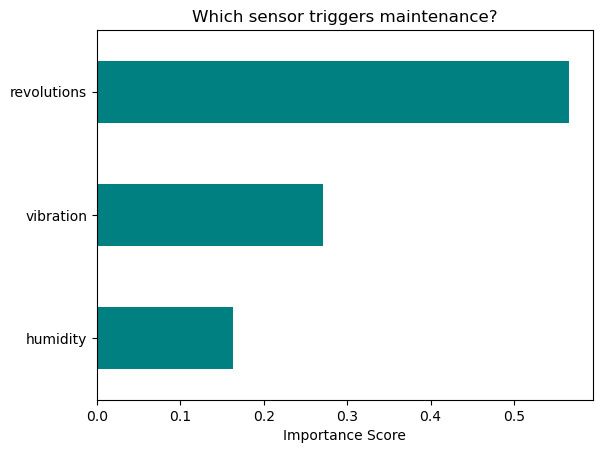

Model trained and 'clf' is now defined!


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define Features (X) and Target (y)
X = df[['revolutions', 'humidity', 'vibration']]
y = df['needs_maintenance']

# 2. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the model (This defines 'clf')
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Now calculate importance (This won't throw an error now!)
importances = pd.Series(clf.feature_importances_, index=['revolutions', 'humidity', 'vibration'])

# 5. Plot the results
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Which sensor triggers maintenance?')
plt.xlabel('Importance Score')
plt.show()

print("Model trained and 'clf' is now defined!")

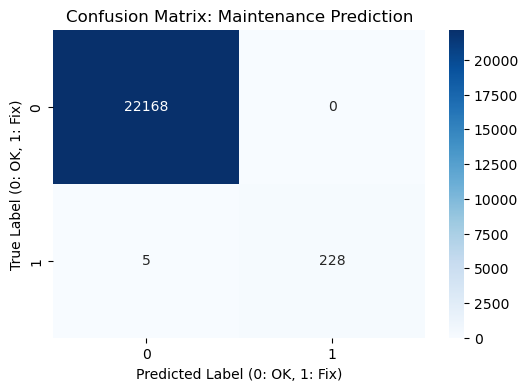

In [50]:
from sklearn.metrics import confusion_matrix  # <--- Add this line!
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure you run the prediction first if you haven't:
y_pred = clf.predict(X_test)

# Now this will work:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label (0: OK, 1: Fix)')
plt.ylabel('True Label (0: OK, 1: Fix)')
plt.title('Confusion Matrix: Maintenance Prediction')
plt.show()

In [51]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Use the model to make predictions on the test data
y_pred = clf.predict(X_test)

# 2. Calculate the Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.98%
------------------------------
Detailed Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22168
           1       1.00      0.98      0.99       233

    accuracy                           1.00     22401
   macro avg       1.00      0.99      0.99     22401
weighted avg       1.00      1.00      1.00     22401



In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix


# 1. LOAD DATA
# Assuming df is already loaded from your CSV
df = pd.read_csv("predictive-maintenance-dataset.csv")

# Ensure data is sorted by ID/Time for rolling windows to make sense
df = df.sort_values('ID').reset_index(drop=True)

# 2. FEATURE ENGINEERING
print("Engineering features...")

# A. Rolling Statistics (Window of 10)
# Captures trends and noise levels
for col in ['revolutions', 'humidity', 'vibration']:
    df[f'{col}_rolling_mean'] = df[col].rolling(window=10).mean()
    df[f'{col}_rolling_std'] = df[col].rolling(window=10).std()

# B. Lag Features (What happened in the previous step?)
for col in ['revolutions', 'humidity', 'vibration']:
    df[f'{col}_lag1'] = df[col].shift(1)

# C. Interaction Features (Physics-based)
# Mechanical stress: vibration relative to speed
df['vib_rev_ratio'] = df['vibration'] / (df['revolutions'] + 1e-6) 
# Environmental stress: humidity affecting vibration
df['hum_vib_intensity'] = df['humidity'] * df['vibration']

# D. Drop rows with NaNs created by rolling/lagging
df = df.dropna().reset_index(drop=True)

# 3. ANOMALY DETECTION (Refined Isolation Forest)
# We use the raw features to define "Maintenance Needed"
scaler = StandardScaler()
###features_for_anomaly = [
###    'revolutions', 'humidity', 'vibration',
###    'revolutions_rolling_mean', 'humidity_rolling_mean', 'vibration_rolling_mean',
###    'revolutions_rolling_std', 'vibration_rolling_std',
###    'revolutions_lag1', 'vibration_lag1',
###    'vib_rev_ratio', 'hum_vib_intensity'
###]

features_for_anomaly = [
    'vibration',
    'vibration_rolling_std',
    'hum_vib_intensity'
]
X_scaled_anomaly = scaler.fit_transform(df[features_for_anomaly])

iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['needs_maintenance'] = iso_forest.fit_predict(X_scaled_anomaly)
# Convert -1 to 1 (Maintenance) and 1 to 0 (OK)
df['needs_maintenance'] = df['needs_maintenance'].apply(lambda x: 1 if x == -1 else 0)

# 4. PREDICTIVE MODELING (Using Engineered Features)
# Now the classifier sees the "future" context and the "history" context
engineered_features = [
    'vibration',
    'vibration_rolling_std',
    'hum_vib_intensity'
]

X = df[engineered_features]
y = df['needs_maintenance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. TRAIN ENHANCED CLASSIFIER
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# 6. EVALUATE
y_pred = clf.predict(X_test)
print("\n--- Enhanced Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred)) 

# Display Feature Importance
importances = pd.Series(clf.feature_importances_, index=engineered_features).sort_values(ascending=False)
print("\nTop 5 Engineered Features:")
print(importances.head(5))

Engineering features...

--- Enhanced Model Performance ---
Accuracy: 99.98%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17920
           1       1.00      0.98      0.99       180

    accuracy                           1.00     18100
   macro avg       1.00      0.99      1.00     18100
weighted avg       1.00      1.00      1.00     18100

[[17920     0]
 [    3   177]]

Top 5 Engineered Features:
vibration                0.387398
vibration_rolling_std    0.310502
hum_vib_intensity        0.302100
dtype: float64


In [3]:
df

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5,revolutions_rolling_mean,...,humidity_rolling_mean,humidity_rolling_std,vibration_rolling_mean,vibration_rolling_std,revolutions_lag1,humidity_lag1,vibration_lag1,vib_rev_ratio,hum_vib_intensity,needs_maintenance
0,10,93.709,73.996,18.01,167.705,19.713,1.266406,8781.376681,5475.408016,93.7266,...,73.9975,0.001080,18.005,0.005270,93.713,73.996,18.01,0.192191,1332.66796,0
1,11,93.705,73.996,18.00,167.701,19.709,1.266352,8780.627025,5475.408016,93.7227,...,73.9972,0.001033,18.005,0.005270,93.709,73.996,18.01,0.192092,1331.92800,0
2,12,93.702,73.995,18.01,167.697,19.707,1.266329,8780.064804,5475.260025,93.7189,...,73.9968,0.001033,18.006,0.005164,93.705,73.996,18.00,0.192205,1332.64995,0
3,13,93.698,73.995,18.01,167.693,19.703,1.266275,8779.315204,5475.260025,93.7151,...,73.9965,0.001080,18.007,0.004830,93.702,73.995,18.01,0.192213,1332.64995,0
4,14,93.694,73.995,18.01,167.689,19.699,1.266221,8778.565636,5475.260025,93.7113,...,73.9962,0.001033,18.008,0.004216,93.698,73.995,18.01,0.192221,1332.64995,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90491,111997,20.186,73.992,2.00,94.178,-53.806,0.272813,407.474596,5474.816064,20.1891,...,73.9920,0.000000,14.616,8.705869,20.187,73.992,20.01,0.099079,147.98400,0
90492,111998,20.186,73.992,20.01,94.178,-53.806,0.272813,407.474596,5474.816064,20.1885,...,73.9920,0.000000,14.614,8.704490,20.186,73.992,2.00,0.991281,1480.57992,0
90493,111999,20.185,73.992,20.01,94.177,-53.807,0.272800,407.434225,5474.816064,20.1879,...,73.9920,0.000000,16.415,7.597376,20.186,73.992,20.01,0.991330,1480.57992,0
90494,112000,20.185,73.992,20.00,94.177,-53.807,0.272800,407.434225,5474.816064,20.1873,...,73.9920,0.000000,16.412,7.595795,20.185,73.992,20.01,0.990835,1479.84000,0
